<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/02_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

USE_DRIVE = True

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv')
    with open('/content/drive/MyDrive/attack_groups.json', 'r') as f:
        attack_groups = json.load(f)
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv')
    print(f"Loaded from upload: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2827876, 79)


In [3]:
print(f"Data shape: {data.shape}")
print(f"\nAttack groups:")
for group_name, attacks in attack_groups.items():
    print(f"  {group_name}: {len(attacks)} attacks")

all_attacks = attack_groups['large'] + attack_groups['medium'] + attack_groups['small']
print(f"\nTotal attacks to process: {len(all_attacks)}")

Data shape: (2827876, 79)

Attack groups:
  large: 4 attacks
  medium: 6 attacks
  small: 4 attacks

Total attacks to process: 14


In [4]:
# All columns except Label are candidate features
feature_cols = [c for c in data.columns if c != 'Label']
print(f"Total candidate features: {len(feature_cols)}")
print(f"\nFirst 10 features: {feature_cols[:10]}")
print(f"Destination Port included: {'Destination Port' in feature_cols}")

Total candidate features: 78

First 10 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
Destination Port included: True


In [5]:
TOP_K = 10
BENIGN_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

benign_data = data[data['Label'] == 'BENIGN']
print(f"BENIGN pool size: {len(benign_data):,}")

# Storage
attack_features = {}            # {attack: [top 10 feature names]}
importance_matrix = {}          # {attack: full importance series} — for heatmap

for i, attack in enumerate(all_attacks, 1):
    attack_data = data[data['Label'] == attack]

    # Sample BENIGN (same size for all attacks for consistency)
    benign_sample = benign_data.sample(
        n=min(BENIGN_SAMPLE_SIZE, len(benign_data)),
        random_state=RANDOM_STATE
    )

    # Build OvR dataset
    ovr_data = pd.concat([benign_sample, attack_data])
    X = ovr_data[feature_cols]
    y = (ovr_data['Label'] == attack).astype(int)

    print(f"[{i:2d}/{len(all_attacks)}] {attack:<35} "
          f"BENIGN={len(benign_sample):>6,} attack={len(attack_data):>6,}", end=' ')

    # Train RF
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    rf.fit(X, y)

    # Extract importance
    importance = pd.Series(rf.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=False)

    top_features = importance.head(TOP_K).index.tolist()
    attack_features[attack] = top_features
    importance_matrix[attack] = importance

    print(f"-> top: {top_features[0][:25]}")

print("\nDone.")

BENIGN pool size: 2,271,320
[ 1/14] DoS Hulk                            BENIGN=50,000 attack=230,124 -> top: Bwd Packets/s
[ 2/14] PortScan                            BENIGN=50,000 attack=158,804 -> top: Bwd Packets/s
[ 3/14] DDoS                                BENIGN=50,000 attack=128,025 -> top: Fwd Packet Length Mean
[ 4/14] DoS GoldenEye                       BENIGN=50,000 attack=10,293 -> top: Flow Packets/s
[ 5/14] FTP-Patator                         BENIGN=50,000 attack= 7,935 -> top: Destination Port
[ 6/14] SSH-Patator                         BENIGN=50,000 attack= 5,897 -> top: Destination Port
[ 7/14] DoS slowloris                       BENIGN=50,000 attack= 5,796 -> top: Avg Bwd Segment Size
[ 8/14] DoS Slowhttptest                    BENIGN=50,000 attack= 5,499 -> top: Flow Packets/s
[ 9/14] Bot                                 BENIGN=50,000 attack= 1,956 -> top: Destination Port
[10/14] Web Attack - Brute Force            BENIGN=50,000 attack= 1,507 -> top: Init_Win_bytes_b

In [6]:
for group_name in ['large', 'medium', 'small']:
    print(f"\n{'='*70}")
    print(f"  {group_name.upper()} ATTACKS")
    print('='*70)
    for attack in attack_groups[group_name]:
        print(f"\n[{attack}]")
        for rank, feat in enumerate(attack_features[attack], 1):
            imp = importance_matrix[attack][feat]
            print(f"  {rank:2d}. {feat:<40} {imp:.4f}")


  LARGE ATTACKS

[DoS Hulk]
   1. Bwd Packets/s                            0.0873
   2. Max Packet Length                        0.0820
   3. Packet Length Std                        0.0726
   4. Avg Bwd Segment Size                     0.0618
   5. Average Packet Size                      0.0518
   6. Destination Port                         0.0467
   7. Packet Length Variance                   0.0432
   8. Packet Length Mean                       0.0418
   9. Bwd Packet Length Max                    0.0407
  10. Bwd Packet Length Std                    0.0385

[PortScan]
   1. Bwd Packets/s                            0.0839
   2. Fwd Packet Length Mean                   0.0778
   3. Subflow Fwd Bytes                        0.0675
   4. Total Length of Fwd Packets              0.0596
   5. Average Packet Size                      0.0563
   6. Packet Length Mean                       0.0485
   7. Flow IAT Max                             0.0436
   8. Flow Duration                      

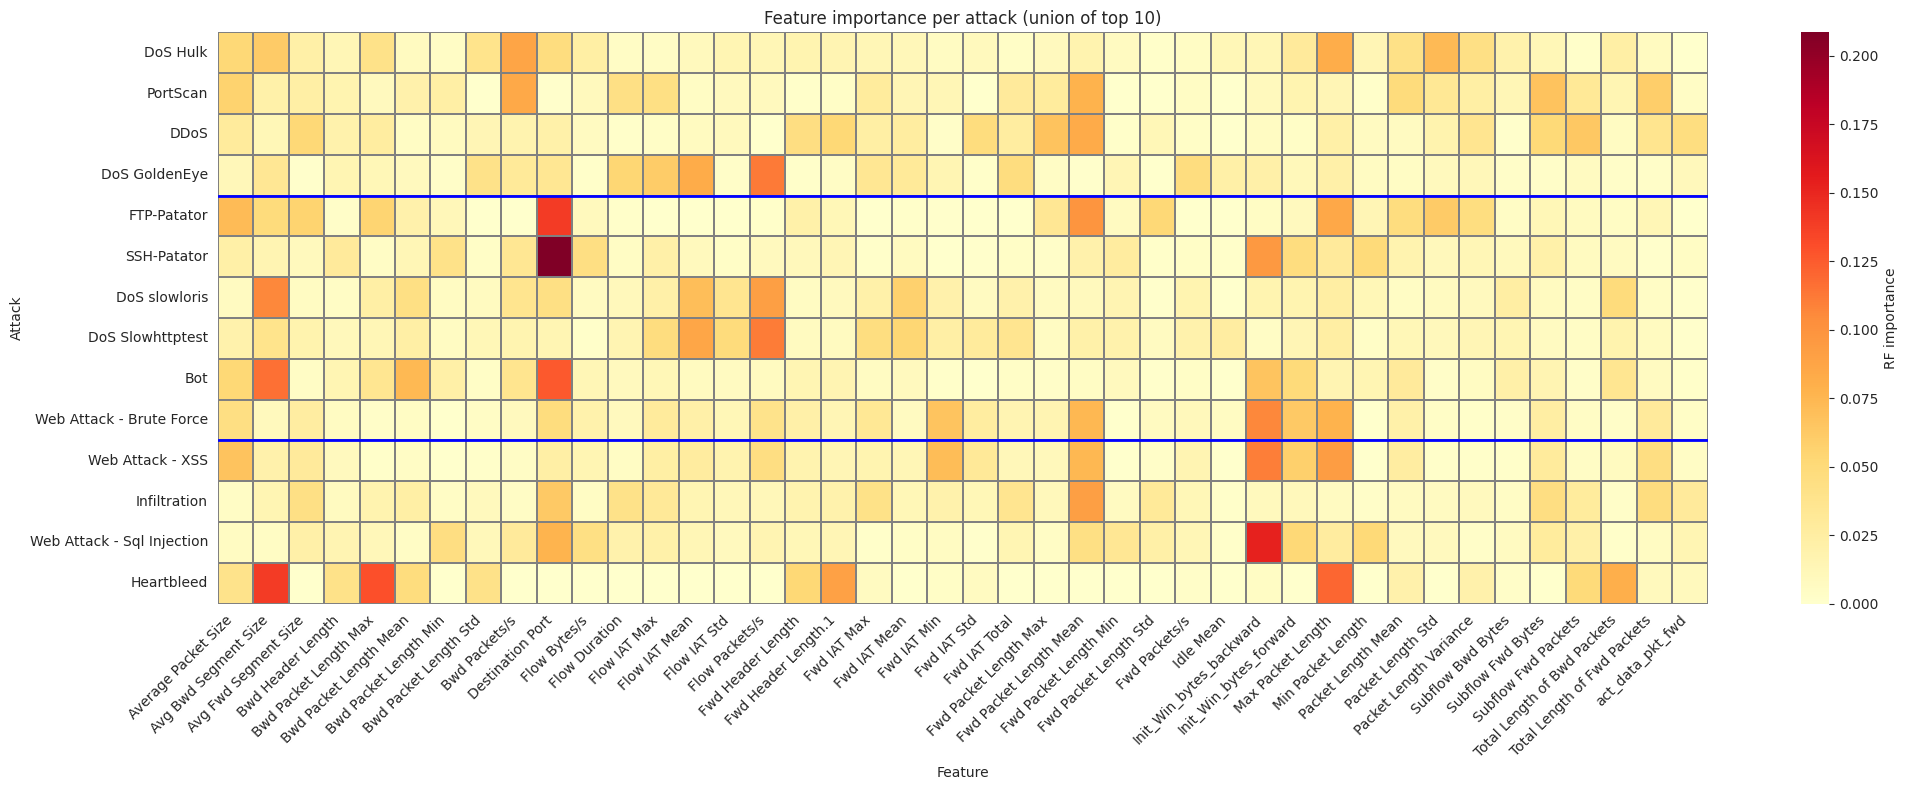


Union size: 42 features (out of 78 candidates)


In [7]:
# Build matrix: rows = attacks, cols = union of top-K features
top_features_union = set()
for attack in all_attacks:
    top_features_union.update(attack_features[attack])
top_features_union = sorted(top_features_union)

heatmap_data = pd.DataFrame(
    index=all_attacks,
    columns=top_features_union,
    dtype=float
)
for attack in all_attacks:
    for feat in top_features_union:
        heatmap_data.loc[attack, feat] = importance_matrix[attack][feat]

# Order rows by group (large -> medium -> small)
row_order = attack_groups['large'] + attack_groups['medium'] + attack_groups['small']
heatmap_data = heatmap_data.loc[row_order]

fig, ax = plt.subplots(figsize=(max(14, len(top_features_union)*0.5), 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'RF importance'},
    ax=ax,
    linewidths=0.3,
    linecolor='gray'
)
ax.set_title(f'Feature importance per attack (union of top {TOP_K})')
ax.set_xlabel('Feature')
ax.set_ylabel('Attack')

# Group dividers
n_large = len(attack_groups['large'])
n_medium = len(attack_groups['medium'])
ax.axhline(n_large, color='blue', linewidth=2)
ax.axhline(n_large + n_medium, color='blue', linewidth=2)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nUnion size: {len(top_features_union)} features "
      f"(out of {len(feature_cols)} candidates)")

In [8]:
output_path = '/content/drive/MyDrive/attack_features.json' if USE_DRIVE else 'attack_features.json'

with open(output_path, 'w') as f:
    json.dump(attack_features, f, indent=2)

print(f"Saved: {output_path}")
print(f"\nPreview:")
for attack in list(attack_features.keys())[:3]:
    print(f"  {attack}: {attack_features[attack][:3]}...")

if not USE_DRIVE:
    from google.colab import files
    files.download('attack_features.json')

Saved: /content/drive/MyDrive/attack_features.json

Preview:
  DoS Hulk: ['Bwd Packets/s', 'Max Packet Length', 'Packet Length Std']...
  PortScan: ['Bwd Packets/s', 'Fwd Packet Length Mean', 'Subflow Fwd Bytes']...
  DDoS: ['Fwd Packet Length Mean', 'Fwd Packet Length Max', 'Subflow Fwd Packets']...
